In [1]:
import sys
import os
import numpy as np
# Get current working directory (where the notebook is running)
notebook_dir = os.getcwd()

# Build path to cec2017-master-py
cec_path = os.path.abspath(os.path.join(notebook_dir, '..', 'cec2017-py-master'))
sys.path.append(cec_path)
from cec2017.functions import all_functions
func_list = all_functions 








In [2]:
def TLBO(func, D=30, pop_size=30, max_evals=30000):
    lb, ub = -100, 100
    evals = 0
    
    def gaussian_mutation(x, lb, ub, sigma=0.05):
        mutation_strength = sigma * (ub - lb)
        noise = np.random.randn(*x.shape) * mutation_strength
        mutated = x + noise
        return np.clip(mutated, lb, ub)

    pop = np.random.uniform(lb, ub, (pop_size, D))
    fitness = np.array([func(x.reshape(1, -1)) for x in pop])
    evals += pop_size

    best_hist = []

    while evals < max_evals:

        # --------- Teacher Phase ---------
        mean = pop.mean(axis=0)
        teacher = pop[np.argmin(fitness)]
        new_pop = pop.copy()

        for i in range(pop_size):
            TF = np.random.randint(1, 3)
            diff = np.random.rand(D) * (teacher - TF * mean)
            candidate = np.clip(pop[i] + diff, lb, ub)

            f_candidate = func(candidate.reshape(1, -1))
            evals += 1

            if f_candidate < fitness[i]:
                new_pop[i] = candidate
                fitness[i] = f_candidate

            if evals >= max_evals:
                break
            
        pop = new_pop

        # --------- Learner Phase ---------
        for i in range(pop_size):
            j = np.random.randint(pop_size)
            while j == i:
                j = np.random.randint(pop_size)

            if fitness[j] < fitness[i]:
                candidate = pop[i] + np.random.rand(D) * (pop[j] - pop[i])
            else:
                candidate = pop[i] - np.random.rand(D) * (pop[j] - pop[i])

            candidate = np.clip(candidate, lb, ub)
            f_candidate = func(candidate.reshape(1, -1))
            evals += 1

            if f_candidate < fitness[i]:
                pop[i] = candidate
                fitness[i] = f_candidate
            
            if evals >= max_evals:
                break

        # --------- Mutation Phase  ---------
        pm = 1.0 / D
        for i in range(pop_size):
            if np.random.rand() < pm:
                mutated = gaussian_mutation(pop[i], lb, ub, sigma=0.05)
                f_mut = func(mutated.reshape(1, -1))
                evals += 1

                if f_mut < fitness[i]:
                    pop[i] = mutated
                    fitness[i] = f_mut

                if evals >= max_evals:
                    break

        best_hist.append(fitness.min())

    return fitness.min(), best_hist


In [6]:
from cec2017.functions import all_functions
func_list = all_functions

results = []  # will store (mean, std)

for idx, func in enumerate(func_list):
    values = []
    for run in range(30):
        best, _ = TLBO(func)
        values.append(best)
    
    values = np.array(values)
    results.append((values.mean(), values.std()))
    print(f"F{idx+1}: mean={values.mean():.4e}, std={values.std():.4e}")



KeyboardInterrupt: 

In [3]:

import matplotlib.pyplot as plt
import importlib
import sys
import os
import numpy as np
# Get current working directory (where the notebook is running)
notebook_dir = os.getcwd()

# Build path to cec2017-master-py
cec_path = os.path.abspath(os.path.join(notebook_dir, '..', 'cec2017-py-master'))
sys.path.append(cec_path)
from cec2017.functions import all_functions
func_list = all_functions 


f2 = func_list[1]
f4 = func_list[3]
f12 = func_list[11]
f25 = func_list[24]


functions = {"f2": f2, "f4": f4, "f12": f12, "f25": f25}

print("✅ Fonctions CEC2017 chargées :", list(functions.keys()))

# Paramètres globaux du benchmark
DIM = 30          # dimension
POP = 30          # taille de population
TMAX = 1000       # nombre d'itérations
STEP = 30         # taille des blocs pour le lissage
LB, UB = -100, 100  # bornes générales des fonctions CEC


✅ Fonctions CEC2017 chargées : ['f2', 'f4', 'f12', 'f25']


In [4]:
def evaluate(func, positions):
    """
    Évalue la fonction sur un ensemble de positions (batch) et renvoie un tableau 1D.
    func : fonction qui prend un array (N, D) et renvoie un array de taille N.
    """
    values = np.asarray(func(positions), dtype=float)
    return values.reshape(values.shape[0]) if values.ndim > 1 else values


In [5]:
def pso_standard(func, rng, D=30, N=30, LB=-100, UB=100,
                 c1=2.0, c2=2.0, Tmax=1000):

    x = rng.uniform(LB, UB, size=(N, D))
    v = np.zeros((N, D))
    pbest = x.copy()
    pbest_values = evaluate(func, x)

    g_best = pbest[np.argmin(pbest_values)].copy()
    history = np.zeros(Tmax)

    for t in range(Tmax):
        w = 0.9 - 0.5 * t / Tmax
        r1 = rng.random((N, D))
        r2 = rng.random((N, D))

        v = w * v + c1 * r1 * (pbest - x) + c2 * r2 * (g_best - x)
        x = np.clip(x + v, LB, UB)
        fitness = evaluate(func, x)

        improved = fitness < pbest_values
        if np.any(improved):
            pbest[improved] = x[improved]
            pbest_values[improved] = fitness[improved]

        g_best = pbest[np.argmin(pbest_values)].copy()
        history[t] = pbest_values.min()

    return g_best, history



def pso_hybrid(func, rng, D=30, N=30, LB=-100, UB=100,
               c1=2.0, c2=2.0, Tmax=1000, p_mut=0.05, sigma=25.0):

    x = rng.uniform(LB, UB, size=(N, D))
    v = np.zeros((N, D))

    pbest = x.copy()
    pbest_values = evaluate(func, x)

    g_best = pbest[np.argmin(pbest_values)].copy()
    history = np.zeros(Tmax)

    for t in range(Tmax):

        w = 0.9 - 0.5 * t / Tmax
        r1, r2 = rng.random((N, D)), rng.random((N, D))

        v = w * v + c1 * r1 * (pbest - x) + c2 * r2 * (g_best - x)
        x += v

        # mutation gaussienne
        mutation_mask = rng.random((N, D)) < p_mut
        x += mutation_mask * rng.normal(0.0, sigma, size=(N, D))

        x = np.clip(x, LB, UB)

        fitness = evaluate(func, x)

        improved = fitness < pbest_values
        if np.any(improved):
            pbest[improved] = x[improved]
            pbest_values[improved] = fitness[improved]

        g_best = pbest[np.argmin(pbest_values)].copy()
        history[t] = pbest_values.min()

    return g_best, history



In [6]:
def ABC(func, rng, D, N, LB, UB, Tmax):
    """
    Artificial Bee Colony (ABC) Algorithm
    Compatible with CEC2017 vectorized functions.

    Parameters:
    - func : vectorized fitness function (expects (N, D) → (N,))
    - rng  : numpy random generator
    - D    : dimension
    - N    : population size (number of food sources)
    - LB, UB : bounds
    - Tmax : number of iterations

    Returns:
    - best_solution : best vector found
    - history       : best fitness at each iteration
    """

    # Number of employed bees = N
    # Number of onlooker bees = N
    # Total population = 2N, but only N food sources
    limit = int(0.5 * D)  # abandonment limit
    
    # Initialize population
    X = rng.uniform(LB, UB, size=(N, D))
    fitness = func(X)
    
    trial = np.zeros(N, dtype=int)
    
    # Best solution
    best_idx = np.argmin(fitness)
    best = X[best_idx].copy()
    best_fit = fitness[best_idx]

    history = [best_fit]

    for t in range(Tmax):

        # ======= PHASE 1 : Employed Bees =======
        for i in range(N):
            # Choose another solution k != i
            k = rng.integers(0, N)
            while k == i:
                k = rng.integers(0, N)

            # Random dimension to perturb
            j = rng.integers(0, D)

            # Generate new solution
            phi = rng.uniform(-1, 1)  # standard ABC perturbation
            v = X[i].copy()
            v[j] += phi * (X[i, j] - X[k, j])

            # Boundary control
            v = np.clip(v, LB, UB)

            # Evaluate
            fv = float(func(v.reshape(1, -1))[0])

            # Greedy selection
            if fv < fitness[i]:
                X[i] = v
                fitness[i] = fv
                trial[i] = 0
            else:
                trial[i] += 1

        # ======= PHASE 2 : Onlooker Bees =======
        prob = (1 / (fitness + 1e-12))  # inverse fitness
        prob /= prob.sum()

        for _ in range(N):
            i = rng.choice(N, p=prob)

            k = rng.integers(0, N)
            while k == i:
                k = rng.integers(0, N)

            j = rng.integers(0, D)

            phi = rng.uniform(-1, 1)
            v = X[i].copy()
            v[j] += phi * (X[i, j] - X[k, j])
            v = np.clip(v, LB, UB)

            fv = float(func(v.reshape(1, -1))[0])

            if fv < fitness[i]:
                X[i] = v
                fitness[i] = fv
                trial[i] = 0
            else:
                trial[i] += 1

        # ======= PHASE 3 : Scout Bees =======
        for i in range(N):
            if trial[i] > limit:
                X[i] = rng.uniform(LB, UB, D)
                fitness[i] = float(func(X[i].reshape(1, -1))[0])
                trial[i] = 0

        # ======= Update global best =======
        idx = np.argmin(fitness)
        if fitness[idx] < best_fit:
            best_fit = fitness[idx]
            best = X[idx].copy()

        history.append(best_fit)

    return best, history


In [8]:
def genetic_algorithm(func, rng, D=30, N=30, LB=-100, UB=100,
                      Tmax=1000, mutation_scale=0.005):
    """
    Algorithme génétique (GA) simple :
    - Croisement à un point (split = D//2)
    - Mutation d'un gène aléatoire par individu
    - Élitisme (on garde toujours les N meilleurs individus)
    """

    split = D // 2
    mutation_amplitude = mutation_scale * (UB - LB)

    # Population initiale
    parents = rng.uniform(LB, UB, size=(N, D))
    fitness = evaluate(func, parents)

    history = np.zeros(Tmax)

    for t in range(Tmax):

        # -----------------------
        # 1. Sélection aléatoire
        # -----------------------
        j = rng.integers(0, N, size=N)
        k = rng.integers(0, N, size=N)

        # -----------------------
        # 2. Croisement
        # -----------------------
        children = np.hstack((parents[j, :split], parents[k, split:]))

        # -----------------------
        # 3. Mutation mono-gène
        # -----------------------
        mutation_idx = rng.integers(0, D, size=N)
        mutation_amount = rng.uniform(-mutation_amplitude, mutation_amplitude, size=N)

        children[np.arange(N), mutation_idx] += mutation_amount

        # Contraintes
        np.clip(children, LB, UB, out=children)

        # -----------------------
        # 4. Évaluation + élitisme
        # -----------------------
        children_fit = evaluate(func, children)

        # Regroupe tout
        combined = np.vstack((parents, children))
        combined_fit = np.concatenate((fitness, children_fit))

        # Trie et garde les meilleurs
        best_idx = np.argsort(combined_fit)[:N]
        parents = combined[best_idx]
        fitness = combined_fit[best_idx]

        # Sauvegarde de la meilleure fitness
        history[t] = fitness[0]

    # Retourne le meilleur individu + historique
    best = parents[np.argmin(fitness)]
    return best, history


In [9]:
def moyenne_blocs(values, pas=30, evals_par_iter=POP):
    """
    Calcule la moyenne par blocs de 'pas' itérations.
    Retourne :
      - x_axis : nombre total d'évaluations pour chaque bloc
      - y_axis : moyenne des valeurs de 'values' dans ce bloc
    """
    n_blocs = len(values) // pas
    moyennes = [
        np.mean(values[i * pas : (i + 1) * pas])
        for i in range(n_blocs)
    ]
    # Bloc 1 => pas itérations => pas * evals_par_iter évaluations, etc.
    x_axis = np.arange(1, n_blocs + 1) * pas * evals_par_iter
    return np.array(x_axis), np.array(moyennes)


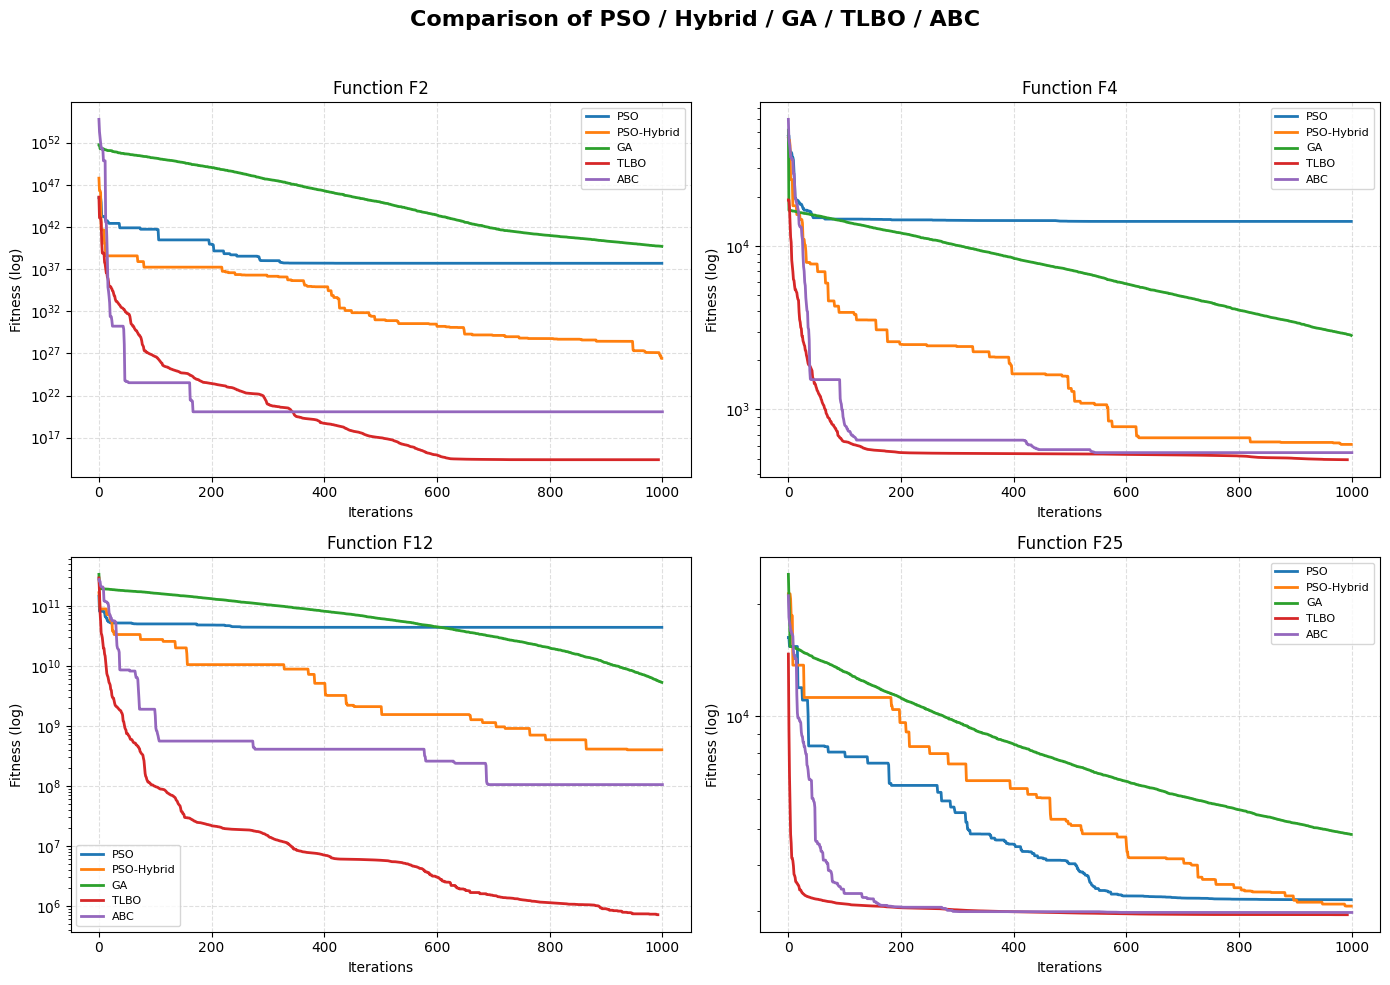

In [10]:
import numpy as np
import matplotlib.pyplot as plt



# ==== 1. Select the functions to plot ====
functions_to_plot = {
    "F2": 1,
    "F4": 3,
    "F12": 11,
    "F25": 24
}

# ==== 2. Run all algorithms on one function ====
def run_all_algos_on_func(func_index):
    f = func_list[func_index]
    rng = np.random.default_rng()

    # ---- vectorized wrapper for PSO, GA, ABC ----
    def vector_func(X):
        X = np.atleast_2d(X).astype(np.float64)
        return f(X)

    # ---- scalar wrapper for TLBO ----
    def scalar_func(x):
        x = np.atleast_1d(x).astype(np.float64).reshape(1, -1)
        out = f(x)
        return float(np.asarray(out).reshape(-1)[0])

    # ---- run algorithms ----
    _, hist_pso    = pso_standard(vector_func, rng, D=DIM, N=POP, LB=LB, UB=UB, Tmax=TMAX)
    _, hist_hybrid = pso_hybrid(vector_func, rng, D=DIM, N=POP, LB=LB, UB=UB, Tmax=TMAX)
    _, hist_ga     = genetic_algorithm(vector_func, rng, D=DIM, N=POP, LB=LB, UB=UB, Tmax=TMAX)
    _, hist_tlbo   = TLBO(scalar_func, D=DIM, pop_size=POP, max_evals=STEP * 2020)

    # ==== ABC (added here) ====
    # ABC MUST accept a vector function exactly like PSO & GA
    _, hist_abc    = ABC(vector_func, rng, D=DIM, N=POP, LB=LB, UB=UB, Tmax=TMAX)

    return {
        "PSO":        hist_pso,
        "PSO-Hybrid": hist_hybrid,
        "GA":         hist_ga,
        "TLBO":       hist_tlbo,
        "ABC":        hist_abc
    }


# ==== 3. Smoothing ====
def smooth(history, step=1):
    y = [np.mean(history[i:i+step]) for i in range(0, len(history), step)]
    x = list(range(len(y)))
    return x, y


# ==== 4. 2×2 Figure ====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (fname, f_id) in zip(axes, functions_to_plot.items()):
    
    results = run_all_algos_on_func(f_id)

    for algo, history in results.items():
        x, y = smooth(history, step=1)
        ax.plot(x, y, label=algo, linewidth=2)

    ax.set_title(f"Function {fname}")
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Fitness (log)")
    ax.set_yscale("log")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=8)

plt.suptitle("Comparison of PSO / Hybrid / GA / TLBO / ABC", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [8]:
import pandas as pd

df = pd.DataFrame(results, columns=["Mean", "Std"])
df.index = [f"F{i+1}" for i in range(30)]

df.to_csv("TLBO_results.csv")
df


,Mean,Std
F1,8.686882e+06,2.230585e+07
F2,2.441048e+17,6.857015e+17
F3,5.430955e+04,1.114132e+04
F4,5.199848e+02,2.137199e+01
F5,6.205568e+02,2.988138e+01
F6,6.285221e+02,7.289260e+00
F7,8.977602e+02,5.413826e+01
F8,8.928248e+02,1.973513e+01
F9,2.023068e+03,8.071774e+02
F10,8.312229e+03,3.014822e+02
